# Analyzing Urban Heat in Zurich

This notebook is spread into multiple sections for different datasets that are then combined. 

First is the Satellite Data that we load, calculate NDVI for and initially visualize. 

Second is the Zurich Polygon and Income Data which follows the same worfklow. 

Finally, we combine the two datasets to create visualizations of how Income, LST, and NDVI in Zurich districts change over time. 

# Satellite Data

## Data Loading

In [ ]:
import rioxarray # these allow us to create raster datasets which will have three dimensions, time, x and y
import xarray as xr #this one as well
import rasterio
import numpy as np
#load our data from a zarr file
ds = xr.open_dataset("../data/processed/Landsat_Zurich.zarr")
ds

<xarray.Dataset> Size: 272MB
Dimensions:      (time: 14, y: 597, x: 508)
Coordinates:
  * time         (time) datetime64[ns] 112B 1985-01-01 1988-01-01 ... 2024-01-01
  * y            (y) float64 5kB 5.256e+06 5.256e+06 ... 5.239e+06 5.239e+06
  * x            (x) float64 4kB 4.577e+05 4.577e+05 ... 4.728e+05 4.729e+05
Data variables:
    Blue         (time, y, x) float64 34MB ...
    Green        (time, y, x) float64 34MB ...
    NDVI         (time, y, x) float64 34MB ...
    NIR          (time, y, x) float64 34MB ...
    Red          (time, y, x) float64 34MB ...
    spatial_ref  int64 8B ...
    SWIR1        (time, y, x) float64 34MB ...
    SWIR2        (time, y, x) float64 34MB ...
    TIR1         (time, y, x) float64 34MB ...

Our data cube has three dimensions. Time, x and y. Time is in datetime64 that is good. 

We need to know what x and y are, lets check CRS.

In [2]:
print(ds.rio.crs)
#It currently has no crs, set it to EPSG32632 that is the CRS of the satellite tifs.

None


In [3]:
ds = ds.rio.write_crs("EPSG:32632") 
print(ds.rio.crs)

EPSG:32632


EPSG:32632 is the western europe projection covering areas between 6°E and 12°E. It does distort area but only at large scales, considering that we are not near a projection zone boundary and that our area of interest is small this is a good CRS to use. 

#### We can calculate memory size. This is important for GitHub. We also can check what datatypes our data has. 

In [4]:
# Calculate total memory size in Megabytes
memory_mb = ds.nbytes / (1024**2)
print(f"Total size: {memory_mb:.2f} MB") #its somewhat large

# Check datatypes
ds.dtypes #all of the Band values are floats, thats good we don't need to retype any data. 

Total size: 259.16 MB


Frozen({'Blue': dtype('<f8'), 'Green': dtype('<f8'), 'NDVI': dtype('<f8'), 'NIR': dtype('<f8'), 'Red': dtype('<f8'), 'SWIR1': dtype('<f8'), 'SWIR2': dtype('<f8'), 'TIR1': dtype('<f8')})

Our dataset is somewhat large but as a .zarr file it will be below GitHubs limits. 

## Data Processing
### Calculate NDVI

NDVI = (NIR - Red) / (NIR + Red)

In [5]:
ds["NDVI"] = (ds["NIR"] - ds["Red"])/(ds["NIR"] + ds["Red"])
#now it gets added to the dataset as a new variable
ds

<xarray.Dataset> Size: 272MB
Dimensions:      (time: 14, y: 597, x: 508)
Coordinates:
  * time         (time) datetime64[ns] 112B 1985-01-01 1988-01-01 ... 2024-01-01
  * y            (y) float64 5kB 5.256e+06 5.256e+06 ... 5.239e+06 5.239e+06
  * x            (x) float64 4kB 4.577e+05 4.577e+05 ... 4.728e+05 4.729e+05
    spatial_ref  int64 8B 0
Data variables:
    Blue         (time, y, x) float64 34MB ...
    Green        (time, y, x) float64 34MB ...
    NDVI         (time, y, x) float64 34MB 0.5065 0.5943 ... 0.7428 0.7326
    NIR          (time, y, x) float64 34MB ...
    Red          (time, y, x) float64 34MB ...
    SWIR1        (time, y, x) float64 34MB ...
    SWIR2        (time, y, x) float64 34MB ...
    TIR1         (time, y, x) float64 34MB ...

## Exploratory Visualization/Analysis
#### We can look at/plot NDVI values in a time series. First a single slice of time. 

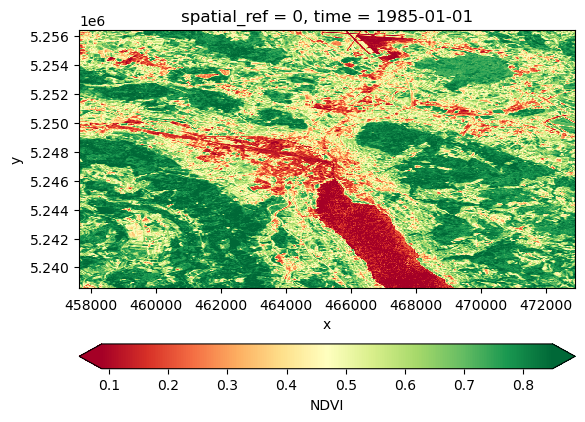

In [6]:
ds.NDVI.sel(time = "1985-01-01").plot.pcolormesh(
    robust=True,
    cmap="RdYlGn",
    cbar_kwargs={
        "orientation": "horizontal",
        "pad": 0.15,
        "label": "NDVI"})

#### Lets make it interactive so we can see over multiple years.


In [78]:
import holoviews as hv
import hvplot.xarray 

hv.extension('bokeh')
# Generate an interactive map with a time slider
ds.NDVI.hvplot(groupby="time",clim = (0, 1), cmap="RdYlGn",
               widget_location = "bottom")
 #clim is 0 to 1 because NDVI values can range from 0 (no vegetation) to 1 (high vegetation)

BokehModel(combine_events=True, render_bundle={'docs_json': {'e43823fb-4b88-4aea-8de0-25b5faa69421': {'version…

### For us the other important variable is Land Surface Temperature (LST). 
LST comes from the TIR1 Band, it is the thermal infrared sensor on the satellite. Lets look at the data array of this band.

In [8]:
ds.TIR1 #Looking at the values. They temperature has already been calculated from the bands for us. 
#Currently they are in Kelvin. Let us convert them to Celsius.
ds["TIR1"] = (ds["TIR1"]-273.15)

#### Same as we did for NDVI. Lets plot LST at a single year and over time. 

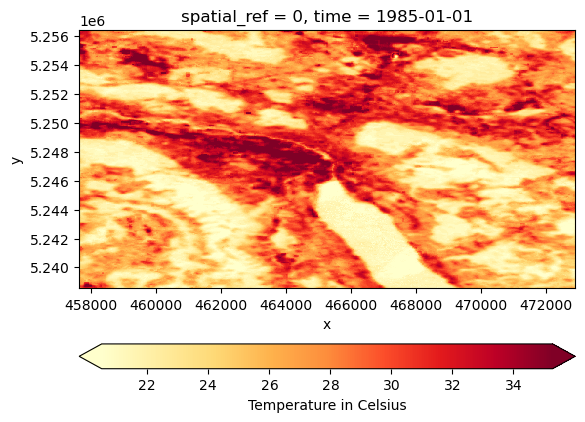

In [9]:
#Single year
LST_1985 = ds.TIR1.sel(time = "1985-01-01").plot.pcolormesh( #what is the pcolormesh?
    robust=True,
    cmap="YlOrRd",
    cbar_kwargs={
        "orientation": "horizontal",
        "pad": 0.15,
        "label": "Temperature in Celsius"})
LST_1985

In [77]:
# Interactive map with a time slider
LST_all = ds.TIR1.hvplot(groupby="time", cmap="YlOrRd",
               widget_location = "bottom") 
#without clim the color bar rescales each year for our exploratory visualization thats ok 
LST_all

BokehModel(combine_events=True, render_bundle={'docs_json': {'aad6619e-5195-446a-8141-60391abde06e': {'version…

Already we can see some patterns. The lake has very low NDVI, this is known as NDVI creates negative or zero values for water bodies. Furthermore we can already see the correlation between NDVI and LST, the forests have much higher vegetation cover and on average also much lower LST. The lake also low LST. The streaks visible in some years are satellite artifacts. 

# Now we move on to Zurich Vector Data
## Data Loading
### Load the Zurich District polygons

In [11]:
import geopandas as gpd
import pandas as pd
Zurich_Districts_gdf = gpd.read_file("../data/raw/Stadtkreise_Zurich.gpkg")

/Users/henristaehelin/miniconda3/envs/zurich-heat/lib/python3.12/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'Stadtkreise_Zurich.gpkg': 'stzh.adm_stadtkreise_v' (default), 'stzh.adm_stadtkreise_a', 'stzh.adm_stadtkreise_beschr_p'. Specify layer parameter to avoid this warning.
  result = read_func(


<Axes: >

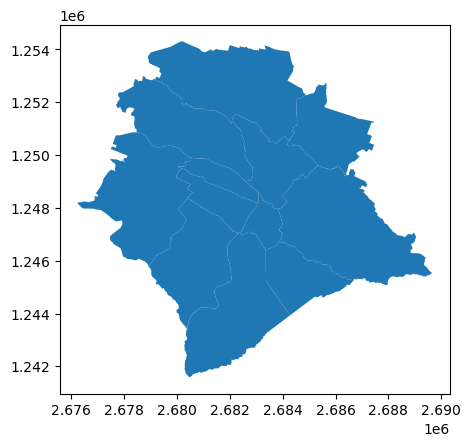

In [12]:
#quick visualizer as a sanity check
Zurich_Districts_gdf.plot()

In [13]:
display(Zurich_Districts_gdf.head()) #the districts aren't in numbered order but there is knr to easily identify which district
print(Zurich_Districts_gdf.crs) # its in LV95 

,objid,objectid,kname,knr,geometry
0,1,1,Kreis 6,6,"POLYGON ((2682070.921 1251415.955, 2682088.088..."
1,10,2,Kreis 11,11,"POLYGON ((2678898.3 1253662.423, 2678898.55 12..."
2,11,3,Kreis 12,12,"POLYGON ((2684161.525 1250427.079, 2684165.228..."
3,12,4,Kreis 10,10,"POLYGON ((2677686.631 1251901.06, 2677687.451 ..."
4,2,5,Kreis 4,4,"POLYGON ((2679958.008 1249151.692, 2679977.864..."


EPSG:2056


In [14]:
#we will convert it to the same CRS as our raster data EPSG:32632
Zurich_Districts_gdf = Zurich_Districts_gdf.to_crs(epsg=32632)
print(Zurich_Districts_gdf.crs)

EPSG:32632


### Load the district income data. 

In [15]:
###Download Zurich Income File per City District (1999-2023)
Zurich_Income_df = gpd.read_file("../data/raw/Einkommen_Stadtquartier.csv")

In [16]:
Zurich_Income_df.head()

,Jahr,Ganze Stadt,Kreis 1,Kreis 2,Kreis 3,Kreis 4,Kreis 5,Kreis 6,Kreis 7,Kreis 8,Kreis 9,Kreis 10,Kreis 11,Kreis 12
0,1999,35,38.1,38,32.9,29.1,32.8,38.1,41.8,40.9,34,38.5,33.8,28.4
1,2000,36.4,40.9,39.5,34.7,30.3,35.1,39.8,43.4,43.8,35,40.1,35,29.8
2,2001,38,42.4,41,36.1,32.2,36.9,41.4,44.9,45.6,36.7,42.1,36.1,30.8
3,2002,38.1,42,40.8,36.2,32,37.8,41.76,45,45,36.6,42.5,36.5,30.9
4,2003,38.1,42.9,40.5,36.2,32.5,38.9,42,45,45.9,36.7,42.3,36.4,30.9


## Data Processing
### Merge it with Zurich Districts so that we have the polygon for each district with our income data.

In [17]:
#we need to reshape the Zurich income to long format currently it is in wide format
# This turns each district name column into a row
income_long = Zurich_Income_df.melt(
    id_vars="Jahr",
    var_name="kname",
    value_name="income"
)
income_long.head() #now we have a column called knname which has all the districts and the entire city (Ganze Stadt)
#it also includes a column called income which are all the income values for each district per year

,Jahr,kname,income
0,1999,Ganze Stadt,35
1,2000,Ganze Stadt,36.4
2,2001,Ganze Stadt,38
3,2002,Ganze Stadt,38.1
4,2003,Ganze Stadt,38.1


In [18]:
# Merge on district name — both files use "kname" as the key
Zurich_gdf = Zurich_Districts_gdf.merge(income_long, on="kname", how="left") #left merge so we keep geometries at all cost even if no income data

Zurich_gdf.head()

,objid,objectid,kname,knr,geometry,Jahr,income
0,1,1,Kreis 6,6,"POLYGON ((464240.659 5250663.579, 464258.061 5...",1999,38.1
1,1,1,Kreis 6,6,"POLYGON ((464240.659 5250663.579, 464258.061 5...",2000,39.8
2,1,1,Kreis 6,6,"POLYGON ((464240.659 5250663.579, 464258.061 5...",2001,41.4
3,1,1,Kreis 6,6,"POLYGON ((464240.659 5250663.579, 464258.061 5...",2002,41.76
4,1,1,Kreis 6,6,"POLYGON ((464240.659 5250663.579, 464258.061 5...",2003,42


In [19]:
print(Zurich_gdf["income"].dtype) # Check what datatype income is, for plotting it needs to be float. 
Zurich_gdf["income"] = Zurich_gdf["income"].astype(float) #convert from string to float

str


In [20]:
Zurich_gdf.income.dtype #Check, yes it is now a float.

dtype('float64')

### Quickly visualize income across zurich districts. 

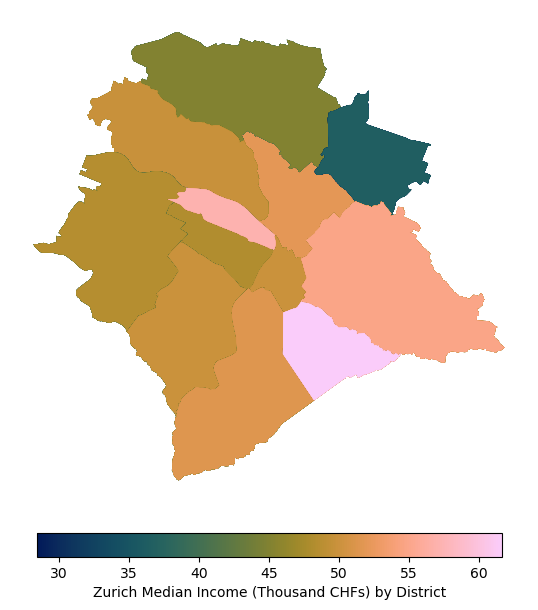

In [21]:
### for a test we could now easily create a chloropleth map of Zurich Districts by income. 
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc #specific color maps

legend_options = {
    "label": "Zurich Median Income (Thousand CHFs) by District",  
    "orientation": "horizontal",  
    "shrink": 0.6,  #size of the color bar
    "pad": 0.05,  #distance from the map
}
fig, ax = plt.subplots(figsize=(10,8))
Zurich_gdf.plot(ax=ax, column = "income", cmap = cmc.batlow, legend=True, legend_kwds=legend_options)
ax.set_axis_off()
plt.show()

This map does not show income over time. We don't even know what year it is from. 

### The Zurich District boundaries extend into forest and lake areas. 
We want to mask these because they skew the NDVI and LST calculations and the goal is to create meaningful district averages of areas in which citizens spend most of their time in. 

### Load the polygon dataset of the citys zoning boundaries. 

In [22]:
#This file contains the building zones of Zurich, including forest and water body zones. 
Zurich_Zones_gdf = gpd.read_file("../data/raw/Zones_Zurich.gpkg", layer="afs.bzo_zone_v")
Zurich_Zones_gdf.head() 

,rechtsstatus,mutationsnummer,typ,plan_url,rechtsvorschrift_url,objectid,geometry
0,inKraft,b'',E1,,https://oerebdocs.zh.ch/getDoc?docid=573,1,"POLYGON ((2680342.689 1245389.129, 2680343.455..."
1,inKraft,b'',E1,,https://oerebdocs.zh.ch/getDoc?docid=6808,2,"POLYGON ((2679890.407 1245806.285, 2679899.337..."
2,inKraft,b'',E1,,https://oerebdocs.zh.ch/getDoc?docid=573; http...,3,"POLYGON ((2680609.885 1245074.398, 2680607.728..."
3,inKraft,b'',E1,,https://oerebdocs.zh.ch/getDoc?docid=6808,4,"POLYGON ((2680850.041 1242544.664, 2680873.68 ..."
4,inKraft,b'',E1,,https://oerebdocs.zh.ch/getDoc?docid=601,5,"POLYGON ((2682077.002 1242253.636, 2682080.231..."


In [23]:
Zurich_Zones_gdf["typ"].unique() #the types we want to remove are stored as GWS (water bodies) and WLD (forest)

<ArrowStringArray>
[    'E1',     'NZ',    'Oe5', 'W2bIII',    'Oe2',   'Oe4F',    'WLD',
     'Z7',      'L',     'FP',     'FC',  'IG II',     'FK',     'FA',
     'FE',     'W3',     'W6',  'W2bII',     'E3',   'Oe2F',   'Oe5F',
    'W4b',     'W2',    'QII',     'Oe',     'W4',   'Oe3F',    'Oe6',
   'IG I',      'K',     'W5',     'E2',     'FD',     'QI',    'Oe3',
    'GWS',      'R',      'F',    'Oe7',     'Z5',   'W2bI', 'IG III',
    'Oe4',     'Z6',   'QIII']
Length: 45, dtype: str

In [24]:
#check CRS
Zurich_Zones_gdf.crs


<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [25]:
# to create a mask using a spatial join to remove the water bodies and forests we need to convert to the same CRS as the others 
Zurich_Zones_gdf = Zurich_Zones_gdf.to_crs(epsg=32632)

### We will create a mask that takes away all the forest and water bodies so we are left in the city with only the urban zones. From this we can then calculate meaningful distrct LST and NDVI.
This allows us to look at how LST and NDVI changed in areas that most people actually live and spend their time in.

<ArrowStringArray>
['WLD', 'GWS']
Length: 2, dtype: str


<Axes: >

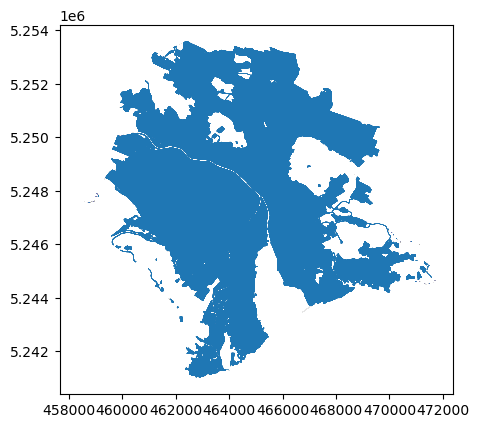

In [26]:
#Step 1. 
Water_Forest = Zurich_Zones_gdf[Zurich_Zones_gdf["typ"].isin(["GWS", "WLD"])] #a true/false mask to isolate the polygons we don't want
print(Water_Forest["typ"].unique()) #check to make sure we only have polygons with WLD or GWS type
#Step 2. Overlay, difference onto a new gdf, we call it Zurich_Bare because it is bare of forests and lakes
Zurich_Bare_gdf = gpd.overlay(Zurich_gdf, Water_Forest, how = "difference") 
#the difference join only keeps the areas that are not "GWS" or "WLD"
#Step 3. Check if it worked with a plot
Zurich_Bare_gdf.plot() #yes all the forest and water polygons have been removed

In [27]:
#check to see the structure of the gdf
Zurich_Bare_gdf #The NAs represent were there were no water or forest zones and thus no zonal data as we masked it. 

,objid,objectid,kname,knr,geometry,Jahr,income
0,1,1,Kreis 6,6,"MULTIPOLYGON (((464290.621 5250697.515, 464310...",1999,38.10
1,1,1,Kreis 6,6,"MULTIPOLYGON (((464290.621 5250697.515, 464310...",2000,39.80
2,1,1,Kreis 6,6,"MULTIPOLYGON (((464290.621 5250697.515, 464310...",2001,41.40
3,1,1,Kreis 6,6,"MULTIPOLYGON (((464290.621 5250697.515, 464310...",2002,41.76
4,1,1,Kreis 6,6,"MULTIPOLYGON (((464290.621 5250697.515, 464310...",2003,42.00
...,...,...,...,...,...,...,...
295,9,12,Kreis 8,8,"MULTIPOLYGON (((465842.251 5245805.915, 465857...",2019,57.80
296,9,12,Kreis 8,8,"MULTIPOLYGON (((465842.251 5245805.915, 465857...",2020,57.80
297,9,12,Kreis 8,8,"MULTIPOLYGON (((465842.251 5245805.915, 465857...",2021,59.00
298,9,12,Kreis 8,8,"MULTIPOLYGON (((465842.251 5245805.915, 465857...",2022,60.90


### Combine satellite raster data with that of the zurich district polygons without forests or water bodies


In [28]:
# A couple of checks before we combine
print(Zurich_Bare_gdf["knr"].sort_index().unique())
print(Zurich_Bare_gdf.crs)
Zurich_Bare_gdf.head()

#It has 12 unique district numbers. 
#it is in the correct CRS
#it will take a while to compute and later plot because the geometry is complicated (lots of small polygons)

[ 6 11 12 10  4  1  9  5  7  3  2  8]
EPSG:32632


,objid,objectid,kname,knr,geometry,Jahr,income
0,1,1,Kreis 6,6,"MULTIPOLYGON (((464290.621 5250697.515, 464310...",1999,38.10
1,1,1,Kreis 6,6,"MULTIPOLYGON (((464290.621 5250697.515, 464310...",2000,39.80
2,1,1,Kreis 6,6,"MULTIPOLYGON (((464290.621 5250697.515, 464310...",2001,41.40
3,1,1,Kreis 6,6,"MULTIPOLYGON (((464290.621 5250697.515, 464310...",2002,41.76
4,1,1,Kreis 6,6,"MULTIPOLYGON (((464290.621 5250697.515, 464310...",2003,42.00


### We brute force clip it. Using rio.clip() we can clip away all the pixels that are not in the polygon borders. 

In [29]:
ds_clipped = ds.rio.clip(
    Zurich_Bare_gdf.geometry, #we take the geometry
    Zurich_Bare_gdf.crs, #and the crs 
    drop=True #the values outside the Zurich borders become NaN
)
#the nans should be for where it got clipped

In [30]:
ds_clipped

<xarray.Dataset> Size: 152MB
Dimensions:      (time: 14, x: 405, y: 418)
Coordinates:
  * time         (time) datetime64[ns] 112B 1985-01-01 1988-01-01 ... 2024-01-01
  * x            (x) float64 3kB 4.594e+05 4.594e+05 ... 4.715e+05 4.715e+05
  * y            (y) float64 3kB 5.254e+06 5.254e+06 ... 5.241e+06 5.241e+06
    spatial_ref  int64 8B 0
Data variables:
    Blue         (time, y, x) float64 19MB nan nan nan nan ... nan nan nan nan
    Green        (time, y, x) float64 19MB nan nan nan nan ... nan nan nan nan
    NDVI         (time, y, x) float64 19MB nan nan nan nan ... nan nan nan nan
    NIR          (time, y, x) float64 19MB nan nan nan nan ... nan nan nan nan
    Red          (time, y, x) float64 19MB nan nan nan nan ... nan nan nan nan
    SWIR1        (time, y, x) float64 19MB nan nan nan nan ... nan nan nan nan
    SWIR2        (time, y, x) float64 19MB nan nan nan nan ... nan nan nan nan
    TIR1         (time, y, x) float64 19MB nan nan nan nan ... nan nan nan nan

## Visualization 

### For our maps it is still useful to have a plot of our district boundaries that we can overlay. 
We can use geoviews to plot the vector lines which can be overlayed on interactive holoviews plots. 

In [50]:
#create a plot of the district polygons

import hvplot.xarray
import hvplot.pandas
import geoviews as gv
import cartopy.crs as ccrs #this lets us explicitly state which crs we are in 
#Need to check if we actually need this or can do smth like crs = target_crs

gv.extension("bokeh")

districts_gv = gv.Polygons(
    Zurich_gdf, #keep Zurich_gdf not Zurich_Bare_gdf because we already clipped it, this is just to show the district borders
    crs=ccrs.UTM(zone=32) #geoviews usually expects WGS84, so we need to explicitly say we are in this CRS
).opts(
    line_color="black",
    fill_alpha=0,
    line_width=1,
    width=800,
    height=800
)

### Plot the NDVI from the clipped dataset over time. We overlay the district boundaries for clarity.

In [52]:
# Interactive NDVI raster
ndvi_plot = ds_clipped.NDVI.hvplot(
    x="x", y="y",               
    groupby="time",             
    cmap="RdYlGn",
    clim=(0, 1),
    width=600, height=600,
    crs=ccrs.UTM(zone=32),   
    title="NDVI Zürich",
    dynamic = False #pre renders all frames to increase interaction speed but also increases load time 
)


# Save plot ndvi with the districts overlayed to html file
citywide_ndvi_plot = ndvi_plot * districts_gv
hvplot.save(citywide_ndvi_plot, '../outputs/citywide_ndvi_map.html')

### Do the same for LST

In [53]:
# Interactive LST raster
LST_plot = ds_clipped.TIR1.hvplot(
    x="x", y="y",               
    groupby="time",             
    cmap="YlOrRd",
    clim=(15,55),
    width=600, height=600,
    crs=ccrs.UTM(zone=32),      
    title="LST Zürich in Celsius",
    dynamic = False #this pre renders all frames, it increases load time but interaction speed is much better
)

# Save LST plot with the districts overlayed to html file
citywide_LST_plot = LST_plot * districts_gv
hvplot.save(citywide_LST_plot, '../outputs/citywide_LST_map.html')

### We have created time series maps for Zurich Income, NDVI and LST for the entire city. 

## Analysis
### We use the package Zonal Stats to compute averages across districts. 

In [34]:
### Convert GeoDataframe into a raster using Geocube
from geocube.api.core import make_geocube
from xrspatial import zonal_stats

#### Step 1: Rasterize the district polygons into an xarray dataset.

In [35]:
# use one year's slice as the spatial template
template = ds_clipped['NDVI'].sel(time="1985-01-01") 

# rasterize district polygons to match the raster grid
districts_unique = Zurich_Bare_gdf.drop_duplicates('knr') #because our data is in long format
#there are multiple values of the same district for multiple years. E.g. Kreis 6 in 2000, Kreis 6 in 2003 etc 
#therefore we drop the duplicates when rasterizing

zones_raster = make_geocube(
    vector_data=districts_unique,
    measurements=['knr'],
    like=template, #the function uses the already xarray dataset/frame dimensions as a template
    #in this case we want just the x and y (spatial) and not time because the district polygons always remain the same
)
zones = zones_raster['knr'] #this becomes an xarray data array

In [36]:
zones_raster #the district polygons have now been rasterized and are in an xarray dataset

<xarray.Dataset> Size: 1MB
Dimensions:      (y: 418, x: 405)
Coordinates:
  * y            (y) float64 3kB 5.254e+06 5.254e+06 ... 5.241e+06 5.241e+06
  * x            (x) float64 3kB 4.594e+05 4.594e+05 ... 4.715e+05 4.715e+05
    spatial_ref  int64 8B 0
Data variables:
    knr          (y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan nan

#### Step 2: Calculate NDVI and LST stats for each district across all sample years. 

In [37]:
results = [] #create an empty list

for t in ds_clipped.time.values: #we will loop over each year in the data
    lst_slice = ds_clipped['TIR1'].sel(time=t) #choose the TIR1 (LST) value from each year
    ndvi_slice = ds_clipped['NDVI'].sel(time=t) #choose the NDVI value from each year

    ### KEY PART OF LOOP
    lst_stats = zonal_stats(zones=zones, values=lst_slice) 
    ndvi_stats = zonal_stats(zones=zones, values=ndvi_slice)
    #zonal stats identifies what zone each pixel is part of and then calculates statistics for each zone
    #by using time slicing we can have it do this for each year in our time series

    merged = lst_stats[['zone', 'mean']].rename(columns={'mean': 'LST_mean'}) #create a df called merged, rename mean to LST_mean
    merged['NDVI_mean'] = ndvi_stats['mean'] #add the NDVI mean to the merged df
    merged['time'] = t  # keep as datetime64 and add it to the df
    merged['knr'] = merged['zone'].astype(int) #rename zone to District and add it to the df

    results.append(merged) #creates a stacked list of dataframes for each year

Noincome_df = pd.concat(results, ignore_index=True) #combines the stacked list into one dataframe and reset the row index

In [38]:
print(np.unique(Noincome_df.time))
Noincome_df.head(13) #check dataframe

['1985-01-01T00:00:00.000000000' '1988-01-01T00:00:00.000000000'
 '1991-01-01T00:00:00.000000000' '1994-01-01T00:00:00.000000000'
 '1997-01-01T00:00:00.000000000' '2000-01-01T00:00:00.000000000'
 '2003-01-01T00:00:00.000000000' '2006-01-01T00:00:00.000000000'
 '2009-01-01T00:00:00.000000000' '2012-01-01T00:00:00.000000000'
 '2015-01-01T00:00:00.000000000' '2018-01-01T00:00:00.000000000'
 '2021-01-01T00:00:00.000000000' '2024-01-01T00:00:00.000000000']


,zone,LST_mean,NDVI_mean,time,knr
0,1.0,32.839582,0.287018,1985-01-01,1
1,2.0,28.922749,0.557527,1985-01-01,2
2,3.0,30.115162,0.498153,1985-01-01,3
3,4.0,34.908485,0.258112,1985-01-01,4
4,5.0,34.677179,0.236215,1985-01-01,5
5,6.0,30.081982,0.453472,1985-01-01,6
6,7.0,27.341590,0.591357,1985-01-01,7
7,8.0,29.133491,0.508417,1985-01-01,8
8,9.0,31.154412,0.467350,1985-01-01,9
9,10.0,29.010594,0.561570,1985-01-01,10


### Step 3: Merge our zonal stats dataframe with the average income of each zurich district over time
**NOTE:** We create two datasets for analysis as sattelite and income data have varying time series, (1985-2024) and (2000-2023) respectively. So when we merge them here we will only keep years where there is data for both (2000,2003, ..., 2021)

In [39]:
#create a subset of data we want to merge with our "Noincome" data frame
income_lookup = Zurich_Bare_gdf[['knr', 'Jahr', 'income']].copy()

# convert Jahr to datetime64 to match the xarray time values
income_lookup['time'] = pd.to_datetime(income_lookup['Jahr'], format='%Y')

Noincome_df['time'] = pd.to_datetime(Noincome_df['time'])

#merge income from Zurich districts and our Noincome dataframe 
final_df = Noincome_df.merge(income_lookup, left_on=['knr', 'time'], right_on=['knr', 'time'])
final_df

,zone,LST_mean,NDVI_mean,time,knr,Jahr,income
0,1.0,36.683578,0.298395,2000-01-01,1,2000,40.9
1,2.0,31.687715,0.560315,2000-01-01,2,2000,39.5
2,3.0,32.775643,0.527616,2000-01-01,3,2000,34.7
3,4.0,38.711646,0.267587,2000-01-01,4,2000,30.3
4,5.0,37.899596,0.252760,2000-01-01,5,2000,35.1
...,...,...,...,...,...,...,...
91,8.0,34.621374,0.508278,2021-01-01,8,2021,59.0
92,9.0,36.343034,0.487682,2021-01-01,9,2021,45.4
93,10.0,34.699018,0.559853,2021-01-01,10,2021,48.7
94,11.0,35.297896,0.509189,2021-01-01,11,2021,42.7


### Step 4: Correlation
#### Does income have an impact on LST or NDVI values?
Here we use our dataframe with both income and environmental data with dates from 2000-2021. 

In [40]:
from scipy import stats #we use the stats package for a pearson correlation

r_LST, p_LST   = stats.pearsonr(final_df['income'], final_df['LST_mean']) #testing correlation between LST and income
r_ndvi, p_ndvi = stats.pearsonr(final_df['income'], final_df['NDVI_mean']) #testing correlation between NDVI and income

print("Pooled correlations with Income:") 
print(f"  LST r={r_LST:.3f},  p={p_LST:.3f}") #round them to the nearest 3 decimals
print(f" NDVI r={r_ndvi:.3f}, p={p_ndvi:.3f}")


Pooled correlations with Income:
  LST r=-0.076,  p=0.461
 NDVI r=0.061, p=0.555


No it does not. Overall richer districts do not have significantly different LST or NDVI values. 

#### Is there a correlation between NDVI and LST? 
Here we use our other dataframe without income data as we have more data points for it. From 1985-2024.

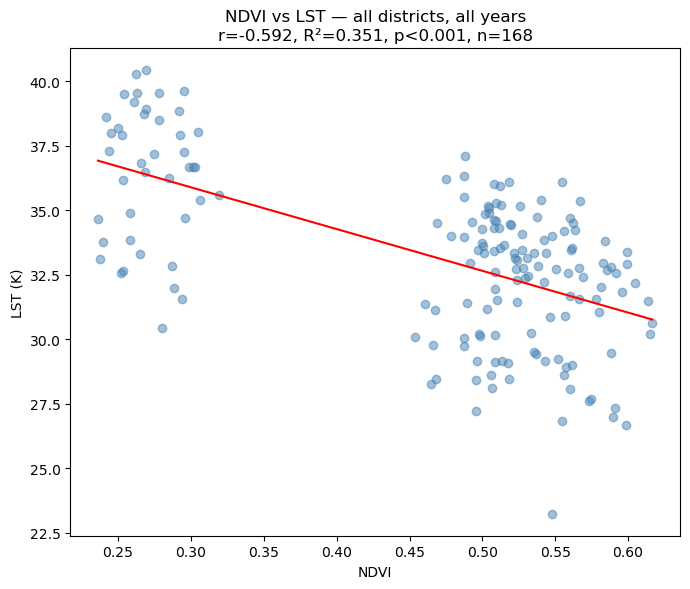

In [ ]:
# We will calculate the correlation and plot the relationship with a trendline.
#Each dot will represent a district average in a certain year
fig, ax = plt.subplots(figsize=(7, 6))

r_full, p_full = stats.pearsonr(Noincome_df['NDVI_mean'], Noincome_df['LST_mean']) 
r_squared = r_full**2 #calculate r squared
#r_full and p _full are for the full range from 1985-2024

# scatter
ax.scatter(Noincome_df['NDVI_mean'], Noincome_df['LST_mean'],
           alpha=0.5, color='steelblue')

# regression line
m, b = np.polyfit(Noincome_df['NDVI_mean'], Noincome_df['LST_mean'], 1) #m, b are slope and intercept in y=mx + b
x_line = np.linspace(Noincome_df['NDVI_mean'].min(), Noincome_df['NDVI_mean'].max(), 100) 
#create a line of 100 randomly generated data values between the minimum and maximum of our data
ax.plot(x_line, m * x_line + b, color='red') #fit that line to our graph with the calculated slope and intercept

ax.set_xlabel('NDVI')
ax.set_ylabel('LST (K)')
ax.set_title(
    f'NDVI vs LST — all districts, all years\n'
    f'r={r_full:.3f}, R²={r_squared:.3f}, p<0.001, n={len(Noincome_df)}'
)

plt.tight_layout()
plt.savefig('Correlation_LST_NDVI.png', dpi=300, bbox_inches='tight')
plt.show()

Yes there is.

### Finally, lets plot NDVI, LST and income per district over time and compare it with Income over time. 

In [42]:
# merge stats with district geometries
Districts_Time = Zurich_Bare_gdf.drop_duplicates('knr').merge(
    Noincome_df, on='knr'  #this is the shared key
)[['knr', 'time', 'NDVI_mean', 'LST_mean', 'geometry']]

In [ ]:
# convert Jahr from a string to an integer so we can create a time slider widget for our income map
Zurich_gdf["Jahr"] = Zurich_gdf["Jahr"].astype("int32")

In [76]:
District_NDVI = Districts_Time.hvplot.polygons(
    geo=True,
    c='NDVI_mean',
    groupby='time',
    cmap='RdYlGn',
    clim = (0.2, 0.7),
    colorbar=True,
    title='Mean NDVI per District',
    hover_cols=["knr", "NDVI_mean"],   
    width=400, height=400,
    crs=ccrs.UTM(zone=32),
    line_color='white',
    dynamic=False # THis makes it so it takes longer to load but is a lot smoother interactively
) * districts_gv               

District_LST = Districts_Time.hvplot.polygons(
    geo=True,
    c='LST_mean',
    groupby='time',
    cmap='YlOrRd',
    clim = (14,45),
    colorbar=True,
    title='Mean LST per District',
    hover_cols=["knr", "LST_mean"],
    width=400, height=400,
    crs=ccrs.UTM(zone=32),
    line_color='white',
    dynamic=False 
) * districts_gv

##plot them together 
District_environment_maps = (District_LST + District_NDVI).cols(1)

#For income over time we can use our original zurich districts and income gdf
Income_plot = Zurich_gdf.hvplot.polygons(
    geo=True,
    c='income',
    groupby='Jahr',
    cmap='viridis',
    clim=(25, 65),
    colorbar=True,
    title='Mean Income per District',
    hover_cols=["kname", "income"],
    width=400, height=400,
    crs=ccrs.UTM(zone=32),
    line_color='white',
    dynamic=False, 
    xaxis = None,
    yaxis = None
)

#loading income and environmental variables together is not possible so save them separately 
hvplot.save(District_environment_maps, "../outputs/District_environment_maps.html")
hvplot.save(Income_plot, "../outputs/income_plot.html")

### Map overall change for each district for NDVI, LST and Income

In [46]:
#Create dataframes of NDVI and LST values for 1985 and 2024
y1985 = Districts_Time[Districts_Time["time"]=="1985-01-01"].set_index("knr")[["NDVI_mean", "LST_mean", "geometry"]]
y2024 = Districts_Time[Districts_Time["time"]=="2024-01-01"].set_index("knr")[["NDVI_mean", "LST_mean", "geometry"]]

#Do the same for income but using the original income dataframe
income_1999 = Zurich_gdf[Zurich_gdf["Jahr"]==1999].set_index("knr")[["income", "geometry"]]
income_2023= Zurich_gdf[Zurich_gdf["Jahr"]==2023].set_index("knr")[["income", "geometry"]]

In [47]:
#Calculate the change for each of these factors
change = gpd.GeoDataFrame({
    "delta_NDVI": y2024["NDVI_mean"].values - y1985["NDVI_mean"].values,
    "delta_LST":  y2024["LST_mean"].values  - y1985["LST_mean"].values,
    "delta_income": income_2023["income"].values - income_1999["income"].values
}, index=y1985.index, geometry=y1985["geometry"], crs=Zurich_Bare_gdf.crs)

### Plot them side by side with the district boundaries overlayed

In [74]:
LST_Change = change.hvplot.polygons(
    geo=True,
    c='delta_LST',
    cmap='cool',
    clim = (0.5, 3.5),
    colorbar=True,
    title='LST Change per District',
    hover_cols=["knr", "delta_LST"],   
    width=400, height=400,
    crs=ccrs.UTM(zone=32),
)*districts_gv

NDVI_Change = change.hvplot.polygons(
    geo=True,
    c='delta_NDVI',
    cmap='YlGnBu',
    clim = (0.01, 0.08),
    colorbar=True,
    title='NDVI Change per District',
    hover_cols=["knr", "delta_NDVI"],   
    width=400, height=400,
    crs=ccrs.UTM(zone=32),
)*districts_gv

Income_Change = change.hvplot.polygons(
    geo=True,
    c='delta_income',
    cmap = cmc.batlow,
    clim = (8,25),
    colorbar=True,
    title = 'Income Change per District',
    hover_cols =["knr", "delta_income"],
    width = 400, height = 400,
    crs=ccrs.UTM(zone=32),
)*districts_gv

District_Change = NDVI_Change + LST_Change + Income_Change
hvplot.save(District_Change, "../outputs/District_Change.html")


A standout district here is district 5 which had the highest income increase, lowest LST increase and the second highest increase in NDVI.

### Does change in income reflect change in NDVI or LST? Do changes in NDVI lead to changes in LST?
Here we correlate changes in income with changes in NDVI and LST to see if areas that had higher income increases also had higher increases in NDVI or LST. Also we want to identify if the increases in NDVI actually lead to decreases in LST or if this effect is counterbalanced by global warming.

In [49]:
# sort first
final_df = final_df.sort_values(['knr', 'time'])

# compute changes within each district
final_df['ΔNDVI']   = final_df.groupby('knr')['NDVI_mean'].diff()
final_df['ΔLST']    = final_df.groupby('knr')['LST_mean'].diff()
final_df['Δincome'] = final_df.groupby('knr')['income'].diff()

# drop first period (NaN from diff)
diff_df = final_df.dropna(subset=['ΔNDVI', 'ΔLST', 'Δincome'])

# correlations
r1, p1 = stats.pearsonr(diff_df['Δincome'], diff_df['ΔNDVI'])
r2, p2 = stats.pearsonr(diff_df['Δincome'], diff_df['ΔLST'])
r3, p3 = stats.pearsonr(diff_df['ΔNDVI'],   diff_df['ΔLST'])

print(f"Δincome vs ΔNDVI: r={r1:.3f}, p={p1:.3f}")
print(f"Δincome vs ΔLST:  r={r2:.3f}, p={p2:.3f}")
print(f"ΔNDVI   vs ΔLST:  r={r3:.3f}, p={p3:.3f}")

Δincome vs ΔNDVI: r=0.278, p=0.011
Δincome vs ΔLST:  r=-0.217, p=0.048
ΔNDVI   vs ΔLST:  r=-0.111, p=0.317
